In [ ]:
# Check that SQLite is available
import sqlite3

print("SQLite is ready!")

SQLite is ready!


In [ ]:
%%writefile generate_data.py
import sqlite3, random, csv
from datetime import date, timedelta

random.seed(42)

conn = sqlite3.connect("bigbasket_capstone.db")
cur = conn.cursor()

cur.executescript("""
DROP TABLE IF EXISTS products;
DROP TABLE IF EXISTS customers;
DROP TABLE IF EXISTS orders;
DROP TABLE IF EXISTS category_targets;

CREATE TABLE products (
    product_id INTEGER PRIMARY KEY,
    product_name TEXT NOT NULL,
    category TEXT NOT NULL,
    supplier TEXT NOT NULL,
    unit_price_inr INTEGER NOT NULL
);
CREATE TABLE customers (
    customer_id INTEGER PRIMARY KEY,
    name TEXT NOT NULL,
    signup_date TEXT NOT NULL,
    city TEXT NOT NULL
);
CREATE TABLE orders (
    order_id INTEGER PRIMARY KEY,
    customer_id INTEGER NOT NULL,
    product_id INTEGER NOT NULL,
    order_date TEXT NOT NULL,
    quantity INTEGER NOT NULL,
    amount_inr INTEGER NOT NULL,
    payment_mode TEXT NOT NULL,
    status TEXT NOT NULL,
    rating INTEGER,
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id),
    FOREIGN KEY (product_id) REFERENCES products(product_id)
);
CREATE TABLE category_targets (
    category TEXT PRIMARY KEY,
    target_revenue_inr INTEGER NOT NULL
);
""")

cities = ["Bengaluru", "Mumbai", "Hyderabad", "Pune"]

products_raw = [
    ("Banana 1kg", "Fruits & Vegetables", "FreshFarms Co", 50),
    ("Tomato 1kg", "Fruits & Vegetables", "FreshFarms Co", 40),
    ("Onion 1kg", "Fruits & Vegetables", "GreenValley Traders", 35),
    ("Apple 1kg", "Fruits & Vegetables", "GreenValley Traders", 180),
    ("Spinach Bunch", "Fruits & Vegetables", "FreshFarms Co", 25),
    ("Toned Milk 1L", "Dairy & Eggs", "DairyBest Ltd", 60),
    ("Paneer 200g", "Dairy & Eggs", "DairyBest Ltd", 90),
    ("Eggs (12pc)", "Dairy & Eggs", "CountryEggs Farms", 84),
    ("Curd 400g", "Dairy & Eggs", "DairyBest Ltd", 45),
    ("Butter 100g", "Dairy & Eggs", "CountryEggs Farms", 55),
    ("Potato Chips 90g", "Snacks & Beverages", "SnackHub India", 30),
    ("Cola 750ml", "Snacks & Beverages", "SnackHub India", 45),
    ("Biscuit Pack", "Snacks & Beverages", "BakeHouse Supplies", 35),
    ("Fruit Juice 1L", "Snacks & Beverages", "SnackHub India", 110),
    ("Namkeen 200g", "Snacks & Beverages", "BakeHouse Supplies", 60),
    ("Shampoo 340ml", "Personal Care", "CarePlus Distributors", 220),
    ("Toothpaste 150g", "Personal Care", "CarePlus Distributors", 95),
    ("Soap Bar 125g", "Personal Care", "CarePlus Distributors", 40),
    ("Hand Wash 250ml", "Personal Care", "CarePlus Distributors", 99),
    ("Face Wash 100g", "Personal Care", "CarePlus Distributors", 150),
    ("Dish Wash Bar", "Household Essentials", "HomeEssentials Traders", 20),
    ("Detergent 1kg", "Household Essentials", "HomeEssentials Traders", 130),
    ("Floor Cleaner 1L", "Household Essentials", "HomeEssentials Traders", 145),
    ("Toilet Cleaner 500ml", "Household Essentials", "HomeEssentials Traders", 89),
    ("Garbage Bags (30pc)", "Household Essentials", "HomeEssentials Traders", 75),
    ("Bread Loaf", "Bakery", "BakeHouse Supplies", 45),
    ("Croissant (2pc)", "Bakery", "BakeHouse Supplies", 70),
    ("Muffin Pack (4pc)", "Bakery", "BakeHouse Supplies", 120),
    ("Cake Slice", "Bakery", "BakeHouse Supplies", 85),
    ("Cookies 200g", "Bakery", "BakeHouse Supplies", 65),
    ("Premium Face Cream 50g", "Personal Care", "CarePlus Distributors", 450),
]
# Note: "Premium Face Cream 50g" (product_id 31) is deliberately excluded from
# popularity_weights/product_ids_weighted below, so it never receives an order —
# this gives the Task 4(b) LEFT JOIN a genuine zero-order row to preserve.
products = [(i, *p) for i, p in enumerate(products_raw, start=1)]
cur.executemany("INSERT INTO products VALUES (?,?,?,?,?)", products)

first_names = ["Aarav","Vivaan","Aditya","Vihaan","Arjun","Sai","Reyansh","Ayaan","Krishna","Ishaan",
               "Ananya","Diya","Saanvi","Aadhya","Kiara","Myra","Anika","Navya","Riya","Siya",
               "Rohan","Kabir","Dev","Yash","Aryan","Zara","Meera","Tara","Nisha","Priya",
               "Aman","Rahul","Karan","Varun","Nikhil","Pooja","Neha","Simran","Divya","Isha",
               "Rohit","Sanjay","Vikram","Manish","Deepak","Kavya","Shreya","Anjali","Pallavi","Sneha"]
customers = []
start_signup = date(2025, 1, 1)
for i, fname in enumerate(first_names, start=1):
    city = cities[i % len(cities)]
    signup = start_signup + timedelta(days=random.randint(0, 400))
    customers.append((i, fname, signup.isoformat(), city))
cur.executemany("INSERT INTO customers VALUES (?,?,?,?)", customers)

popularity_weights = [10,8,6,3,5, 9,7,6,8,4, 10,9,5,4,6, 3,5,9,4,3, 8,6,5,4,7, 6,4,3,5,4]
order_date_start = date(2026, 1, 1)
order_date_end = date(2026, 6, 30)
total_days = (order_date_end - order_date_start).days

TOTAL_ORDERS = 500
product_ids_weighted = []
for pid, w in zip(range(1, 31), popularity_weights):
    product_ids_weighted.extend([pid] * w)

payment_modes = ["UPI", "Credit Card", "Debit Card", "Cash on Delivery", "Wallet"]
product_lookup = {p[0]: p for p in products}
customer_lookup = {c[0]: c for c in customers}

orders = []
order_id = 1
for _ in range(TOTAL_ORDERS):
    cust_id = random.randint(1, 50)
    prod_id = random.choice(product_ids_weighted)
    unit_price = product_lookup[prod_id][4]
    quantity = random.randint(1, 5)
    amount = quantity * unit_price
    day_offset = random.randint(0, total_days)
    o_date = order_date_start + timedelta(days=day_offset)
    payment_mode = random.choice(payment_modes)
    roll = random.random()
    if roll < 0.85:
        status = "Delivered"
        rating = random.randint(1, 5)
    elif roll < 0.95:
        status = "Cancelled"
        rating = None
    else:
        status = "Pending"
        rating = None
    orders.append([order_id, cust_id, prod_id, o_date.isoformat(), quantity, amount, payment_mode, status, rating])
    order_id += 1
cur.executemany("INSERT INTO orders VALUES (?,?,?,?,?,?,?,?,?)", [tuple(o) for o in orders])

category_targets = [
    ("Fruits & Vegetables", 12000),
    ("Dairy & Eggs", 16500),
    ("Snacks & Beverages", 13000),
    ("Personal Care", 15500),
    ("Household Essentials", 17000),
    ("Bakery", 12000),
]
cur.executemany("INSERT INTO category_targets VALUES (?,?)", category_targets)

conn.commit()

# --- Raw exports for Part 4 (Python/Pandas) — deliberately messy, do not "fix" here ---
raw_rows = []
for o in orders:
    order_id, cust_id, prod_id, o_date, qty, amt, pm, status, rating = o
    cust = customer_lookup[cust_id]
    raw_rows.append({
        "order_id": order_id, "order_date": o_date, "customer_name": cust[1],
        "city": cust[3], "category": product_lookup[prod_id][2], "product_id": prod_id,
        "quantity": qty, "amount_inr": amt, "payment_mode": pm, "status": status,
        "rating": rating if rating is not None else "",
    })

rng2 = random.Random(7)
casing_idx = rng2.sample(range(len(raw_rows)), 20)
for idx in casing_idx:
    r = raw_rows[idx]
    variant = rng2.choice(["upper", "lower", "space"])
    r["city"] = r["city"].upper() if variant == "upper" else (r["city"].lower() if variant == "lower" else " " + r["city"] + " ")
    variant2 = rng2.choice(["upper", "lower", "space"])
    r["category"] = r["category"].upper() if variant2 == "upper" else (r["category"].lower() if variant2 == "lower" else " " + r["category"] + " ")

null_idx = rng2.sample([i for i in range(len(raw_rows)) if i not in casing_idx], 10)
for idx in null_idx:
    raw_rows[idx]["amount_inr"] = ""

outlier_pool = [i for i in range(len(raw_rows)) if i not in casing_idx and i not in null_idx]
outlier_idx = rng2.sample(outlier_pool, 5)
for idx in outlier_idx:
    raw_rows[idx]["amount_inr"] = raw_rows[idx]["amount_inr"] * 40

dup_pool = [i for i in range(len(raw_rows)) if i not in casing_idx and i not in null_idx and i not in outlier_idx]
dup_idx = rng2.sample(dup_pool, 8)
all_rows = raw_rows + [dict(raw_rows[i]) for i in dup_idx]

fieldnames = ["order_id","order_date","customer_name","city","category","product_id",
              "quantity","amount_inr","payment_mode","status","rating"]
with open("orders_raw.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=fieldnames)
    w.writeheader()
    w.writerows(all_rows)

with open("products.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["product_id", "product_name", "category", "supplier", "unit_price_inr"])
    w.writerows(products)

conn.close()
print("bigbasket_capstone.db, orders_raw.csv, products.csv created.")

Overwriting generate_data.py


In [ ]:
! python generate_data.py

bigbasket_capstone.db, orders_raw.csv, products.csv created.


In [ ]:
%%writefile verify.sql

-- Part 1 Verification
-- Expected results:
-- Products = 31
-- Customers = 50
-- Orders = 500
-- Category Targets = 6
-- Delivered = 434
-- Cancelled = 42
-- Pending = 24

SELECT 'products' AS table_name, COUNT(*) AS row_count
FROM products
UNION ALL
SELECT 'customers', COUNT(*)
FROM customers
UNION ALL
SELECT 'orders', COUNT(*)
FROM orders
UNION ALL
SELECT 'category_targets', COUNT(*)
FROM category_targets;

SELECT status, COUNT(*) AS order_count
FROM orders
GROUP BY status
ORDER BY status;

Writing verify.sql


In [ ]:
%%writefile 01_foundations.sql

-- ==========================================
-- PART 1: FOUNDATIONS
-- ==========================================

-- 1. SELECT / WHERE
-- Orders from a specific city
SELECT *
FROM orders
WHERE city = 'Hyderabad';


-- 2. DISTINCT
-- Every distinct category
SELECT DISTINCT category
FROM products
ORDER BY category;


-- 3. ORDER BY + LIMIT
-- 5 highest-value orders
SELECT order_id, order_date, customer_id, city, amount_inr
FROM orders
ORDER BY amount_inr DESC
LIMIT 5;


-- 4. Alias AS
-- Count total orders
SELECT COUNT(*) AS total_orders
FROM orders;


-- 5. IN
-- Orders using either UPI or Credit Card
SELECT *
FROM orders
WHERE payment_mode IN ('UPI', 'Credit Card');


-- 6. BETWEEN
-- Orders within the stated amount range
SELECT *
FROM orders
WHERE amount_inr BETWEEN 500 AND 2000;


-- 7. NOT BETWEEN
-- Orders outside the stated amount range
SELECT *
FROM orders
WHERE amount_inr NOT BETWEEN 500 AND 2000;


-- 8. IS NULL
-- Orders with no rating
-- Cancelled and Pending orders have no rating
SELECT *
FROM orders
WHERE rating IS NULL;

Writing 01_foundations.sql


In [29]:
%%writefile 02_aggregation_joins.sql

-- ==========================================
-- PART 1: AGGREGATION & JOINS
-- ==========================================

-- 1. INNER JOIN
-- Delivered orders by category
-- Show only categories with total revenue greater than 10,000

SELECT
    p.category,
    COUNT(o.order_id) AS order_count,
    SUM(o.amount_inr) AS total_revenue,
    AVG(o.amount_inr) AS avg_order_value
FROM orders AS o
INNER JOIN products AS p
    ON o.product_id = p.product_id
WHERE o.status = 'Delivered'
GROUP BY p.category
HAVING total_revenue > 10000
ORDER BY total_revenue DESC;


-- 2. LEFT JOIN
-- Count orders for every product
-- Products with zero orders must also appear

SELECT
    p.product_id,
    p.product_name,
    COUNT(o.order_id) AS order_count
FROM products AS p
LEFT JOIN orders AS o
    ON p.product_id = o.product_id
GROUP BY
    p.product_id,
    p.product_name
ORDER BY order_count ASC;

Writing 02_aggregation_joins.sql


In [30]:
%%writefile 03_reporting.sql

-- ==========================================
-- PART 1: REPORTING
-- ==========================================

-- 1. CASE WHEN
-- Classify products by Delivered revenue

SELECT
    p.product_id,
    p.product_name,
    SUM(
        CASE
            WHEN o.status = 'Delivered' THEN o.amount_inr
            ELSE 0
        END
    ) AS delivered_revenue,
    CASE
        WHEN SUM(CASE WHEN o.status = 'Delivered' THEN o.amount_inr ELSE 0 END) >= 3000
            THEN 'High'
        WHEN SUM(CASE WHEN o.status = 'Delivered' THEN o.amount_inr ELSE 0 END) >= 1000
            THEN 'Medium'
        ELSE 'Low'
    END AS revenue_tier
FROM products AS p
LEFT JOIN orders AS o
    ON p.product_id = o.product_id
GROUP BY
    p.product_id,
    p.product_name
ORDER BY delivered_revenue DESC;


-- 2. MONTHLY-BY-CATEGORY REPORT
-- Delivered orders only

SELECT
    p.category AS category,
    strftime('%Y-%m', o.order_date) AS month,
    COUNT(o.order_id) AS order_count,
    SUM(o.amount_inr) AS total_revenue,
    AVG(o.amount_inr) AS avg_revenue
FROM orders AS o
INNER JOIN products AS p
    ON o.product_id = p.product_id
WHERE o.status = 'Delivered'
GROUP BY
    p.category,
    strftime('%Y-%m', o.order_date)
ORDER BY
    category,
    month;


-- 3. CATEGORY TARGET COMPARISON

WITH category_revenue AS (
    SELECT
        p.category,
        SUM(o.amount_inr) AS total_revenue
    FROM orders AS o
    INNER JOIN products AS p
        ON o.product_id = p.product_id
    WHERE o.status = 'Delivered'
    GROUP BY p.category
)

SELECT
    cr.category,
    cr.total_revenue,
    ct.target_revenue_inr,
    ct.target_revenue_inr - cr.total_revenue AS variance,
    ((cr.total_revenue - ct.target_revenue_inr) * 100.0)
        / ct.target_revenue_inr AS percentage_variance,
    CASE
        WHEN cr.total_revenue >= ct.target_revenue_inr
            THEN 'Above Target'
        WHEN (ct.target_revenue_inr - cr.total_revenue) <=
             (ct.target_revenue_inr * 0.15)
            THEN 'Below Target - Watch'
        ELSE 'Below Target - Critical'
    END AS target_status
FROM category_revenue AS cr
INNER JOIN category_targets AS ct
    ON cr.category = ct.category
ORDER BY cr.category;

Writing 03_reporting.sql


In [31]:
%%writefile ai_log.md

# AI LOG — Part 1

## AI-Assisted Prompt #1 (RCTCF)

### Role
Act as a SQL data-analytics assistant helping me write and verify SQLite queries for a BigBasket-style category performance diagnostic.

### Context
I have a deterministic SQLite database named `bigbasket_capstone.db` containing the tables `products`, `customers`, `orders`, and `category_targets`. The database was generated using the supplied `generate_data.py` script with `random.seed(42)`. I need a monthly-by-category revenue report using only Delivered orders.

### Task
Write a SQLite-compatible SQL query that produces a monthly-by-category business report with these five columns exactly:
`category, month, order_count, total_revenue, avg_revenue`.

Use `strftime('%Y-%m', order_date)` for the month, join `orders` with `products`, filter to Delivered orders, group by category and month, and order the result by category and month. The query will be used to create `monthly_category_revenue.csv`.

### Constraints
Use SQLite syntax. Do not modify the generated database or the supplied data. The result must contain 6 categories across 6 months, giving exactly 36 rows. The exported CSV must contain exactly the five required columns and must be a direct, unedited export of the query result.

### Format
Return only the SQL query in a clearly formatted code block, followed by a short explanation of how to verify the result.

## Verification Performed

I ran the AI-suggested monthly-by-category query against `bigbasket_capstone.db`, exported the result directly to `monthly_category_revenue.csv`, and checked that the output contained exactly 36 rows and that the grand total of `total_revenue` was exactly 88282.

Overwriting ai_log.md


In [ ]:
import sqlite3
import pandas as pd
import os

conn = sqlite3.connect("bigbasket_capstone.db")

# 1. Check table row counts
print("=== TABLE COUNTS ===")

tables = ["products", "customers", "orders", "category_targets"]

for table in tables:
    count = pd.read_sql_query(
        f"SELECT COUNT(*) AS count FROM {table}",
        conn
    )["count"][0]
    print(f"{table}: {count}")

# 2. Check order status counts
print("\n=== ORDER STATUS ===")

status_df = pd.read_sql_query("""
SELECT status, COUNT(*) AS order_count
FROM orders
GROUP BY status
ORDER BY status;
""", conn)

print(status_df.to_string(index=False))

# 3. Check Premium Face Cream 50g order count
print("\n=== PREMIUM FACE CREAM CHECK ===")

premium_df = pd.read_sql_query("""
SELECT
    p.product_id,
    p.product_name,
    COUNT(o.order_id) AS order_count
FROM products AS p
LEFT JOIN orders AS o
    ON p.product_id = o.product_id
WHERE p.product_name = 'Premium Face Cream 50g'
GROUP BY p.product_id, p.product_name;
""", conn)

print(premium_df.to_string(index=False))

# 4. Check monthly CSV
print("\n=== MONTHLY CSV CHECK ===")

monthly_df = pd.read_csv("monthly_category_revenue.csv")

print("Rows:", len(monthly_df))
print("Columns:", list(monthly_df.columns))
print("Grand total:", monthly_df["total_revenue"].sum())

# 5. Check required files
print("\n=== FILE CHECK ===")

required_files = [
    "generate_data.py",
    "bigbasket_capstone.db",
    "orders_raw.csv",
    "products.csv",
    "verify.sql",
    "01_foundations.sql",
    "02_aggregation_joins.sql",
    "03_reporting.sql",
    "monthly_category_revenue.csv",
    "ai_log.md"
]

for file in required_files:
    print(f"{file}: {'OK' if os.path.exists(file) else 'MISSING'}")

conn.close()

=== TABLE COUNTS ===
products: 31
customers: 50
orders: 500
category_targets: 6

=== ORDER STATUS ===
   status  order_count
Cancelled           42
Delivered          434
  Pending           24

=== PREMIUM FACE CREAM CHECK ===
 product_id           product_name  order_count
         31 Premium Face Cream 50g            0

=== MONTHLY CSV CHECK ===
Rows: 36
Columns: ['category', 'month', 'order_count', 'total_revenue', 'avg_revenue']
Grand total: 88282

=== FILE CHECK ===
generate_data.py: OK
bigbasket_capstone.db: OK
orders_raw.csv: OK
products.csv: OK
verify.sql: OK
01_foundations.sql: OK
02_aggregation_joins.sql: OK
03_reporting.sql: OK
monthly_category_revenue.csv: OK
ai_log.md: OK


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Part 4 — Load and Inspect

import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv('/content/orders_raw.csv')
products = pd.read_csv('/content/products.csv')

print("Orders shape:", orders.shape)
print("Products shape:", products.shape)

orders.info()

Orders shape: (508, 11)
Products shape: (31, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB


In [ ]:
print("First 5 rows:")
display(orders.head())

print("\nOrder status counts:")
print(orders["status"].value_counts())

print("\nSummary statistics:")
display(orders.describe(include="all"))

First 5 rows:


,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
0,1,2026-03-09,Dev,Pune,Snacks & Beverages,13,5,175.0,UPI,Delivered,5.0
1,2,2026-05-22,Ayaan,Bengaluru,Snacks & Beverages,15,1,60.0,Debit Card,Delivered,5.0
2,3,2026-06-30,Yash,Bengaluru,Household Essentials,25,2,150.0,UPI,Delivered,2.0
3,4,2026-03-01,Sneha,Hyderabad,Snacks & Beverages,11,1,30.0,UPI,Delivered,4.0
4,5,2026-04-05,Rohit,Mumbai,Snacks & Beverages,14,2,220.0,Debit Card,Delivered,3.0



Order status counts:
status
Delivered    439
Cancelled     43
Pending       26
Name: count, dtype: int64

Summary statistics:


,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
count,508.000000,508,508,508,508,508.000000,508.000000,498.000000,508,508,439.000000
unique,NaN,165,50,14,18,NaN,NaN,NaN,5,3,NaN
top,NaN,2026-04-16,Arjun,Mumbai,Household Essentials,NaN,NaN,NaN,Wallet,Delivered,NaN
freq,NaN,10,19,133,94,NaN,NaN,NaN,111,439,NaN
mean,250.204724,NaN,NaN,NaN,NaN,15.476378,3.045276,257.530120,NaN,NaN,3.082005
std,144.594139,NaN,NaN,NaN,NaN,8.747467,1.364497,559.424136,NaN,NaN,1.364126
min,1.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,20.000000,NaN,NaN,1.000000
25%,125.750000,NaN,NaN,NaN,NaN,8.000000,2.000000,90.000000,NaN,NaN,2.000000
50%,249.500000,NaN,NaN,NaN,NaN,15.000000,3.000000,168.000000,NaN,NaN,3.000000
75%,376.250000,NaN,NaN,NaN,NaN,23.000000,4.000000,283.750000,NaN,NaN,4.000000


In [ ]:
# Task 2 — Remove duplicate orders

print("Rows before removing duplicates:", len(orders))

duplicate_count = orders.duplicated(subset="order_id").sum()
print("Duplicate rows found:", duplicate_count)

orders = orders.drop_duplicates(subset="order_id", keep="first").copy()

print("Rows after removing duplicates:", len(orders))
print("Unique order IDs:", orders["order_id"].nunique())

Rows before removing duplicates: 508
Duplicate rows found: 8
Rows after removing duplicates: 500
Unique order IDs: 500


In [ ]:
# Task 3 — Fix casing and whitespace

orders["city"] = orders["city"].str.strip().str.title()
orders["category"] = orders["category"].str.strip().str.title()

print("Unique cities:")
print(sorted(orders["city"].dropna().unique()))

print("\nUnique categories:")
print(sorted(orders["category"].dropna().unique()))

Unique cities:
['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']

Unique categories:
['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']


In [ ]:
# Task 4 — Missing values

print("Missing amount_inr:", orders["amount_inr"].isna().sum())
print("Missing rating:", orders["rating"].isna().sum())

print("\nMissing values in all columns:")
print(orders.isna().sum())

Missing amount_inr: 10
Missing rating: 66

Missing values in all columns:
order_id          0
order_date        0
customer_name     0
city              0
category          0
product_id        0
quantity          0
amount_inr       10
payment_mode      0
status            0
rating           66
dtype: int64


In [ ]:
orders["amount_inr"] = pd.to_numeric(orders["amount_inr"], errors="coerce")

print("Missing amount_inr after conversion:", orders["amount_inr"].isna().sum())

Missing amount_inr after conversion: 10


In [ ]:
print(orders["rating"].isna().sum())
print(orders["rating"].value_counts(dropna=False))

66
rating
3.0    98
4.0    90
5.0    88
2.0    86
1.0    72
NaN    66
Name: count, dtype: int64


In [ ]:
# Task 5 — IQR outlier detection on Delivered orders

delivered = orders[
    (orders["status"] == "Delivered") &
    (orders["amount_inr"].notna())
].copy()

Q1 = delivered["amount_inr"].quantile(0.25)
Q3 = delivered["amount_inr"].quantile(0.75)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower fence:", lower_fence)
print("Upper fence:", upper_fence)

outlier_count = (delivered["amount_inr"] > upper_fence).sum()
print("Number of upper outliers:", outlier_count)

Q1: 90.0
Q3: 275.0
IQR: 185.0
Lower fence: -187.5
Upper fence: 552.5
Number of upper outliers: 16


In [ ]:
# Cap Delivered revenue outliers using the IQR upper fence

delivered["amount_inr_capped"] = delivered["amount_inr"].clip(upper=upper_fence)

capped_count = (delivered["amount_inr"] > upper_fence).sum()

print("Upper fence:", upper_fence)
print("Number of values capped:", capped_count)
print("Maximum amount before capping:", delivered["amount_inr"].max())
print("Maximum amount after capping:", delivered["amount_inr_capped"].max())

Upper fence: 552.5
Number of values capped: 16
Maximum amount before capping: 7600.0
Maximum amount after capping: 552.5


In [ ]:
# Task 6 — Dates and derived columns

orders["order_date"] = pd.to_datetime(orders["order_date"])

orders["month"] = orders["order_date"].dt.to_period("M")
orders["month_name"] = orders["order_date"].dt.month_name()

orders["revenue_per_unit"] = orders["amount_inr"] / orders["quantity"]

orders["is_delivered"] = orders["status"] == "Delivered"

print(orders[[
    "order_date",
    "month",
    "month_name",
    "quantity",
    "amount_inr",
    "revenue_per_unit",
    "is_delivered"
]].head())

  order_date    month month_name  quantity  amount_inr  revenue_per_unit  \
0 2026-03-09  2026-03      March         5       175.0              35.0   
1 2026-05-22  2026-05        May         1        60.0              60.0   
2 2026-06-30  2026-06       June         2       150.0              75.0   
3 2026-03-01  2026-03      March         1        30.0              30.0   
4 2026-04-05  2026-04      April         2       220.0             110.0   

   is_delivered  
0          True  
1          True  
2          True  
3          True  
4          True  


In [ ]:
# Task 7A — Delivered revenue by category

delivered["amount_inr_clean"] = delivered["amount_inr"].clip(upper=upper_fence)

category_revenue = (
    delivered
    .groupby("category", as_index=False)["amount_inr_clean"]
    .sum()
    .rename(columns={"amount_inr_clean": "total_revenue"})
    .sort_values("total_revenue", ascending=False)
)

print("Delivered revenue by category:")
display(category_revenue)

print("Top category:")
print(category_revenue.iloc[0]["category"])

Delivered revenue by category:


,category,total_revenue
3,Household Essentials,20910.0
0,Bakery,14975.0
4,Personal Care,14594.5
1,Dairy & Eggs,13675.0
5,Snacks & Beverages,11312.5
2,Fruits & Vegetables,9170.0


Top category:
Household Essentials


In [ ]:
# Task 7B — Merge orders with products and find top supplier

merged = orders.merge(
    products,
    on="product_id",
    how="left",
    suffixes=("_order", "_product")
)

merged_delivered = merged[
    (merged["status"] == "Delivered") &
    (merged["amount_inr"].notna())
].copy()

merged_delivered["amount_inr_clean"] = merged_delivered["amount_inr"].clip(
    upper=upper_fence
)

supplier_revenue = (
    merged_delivered
    .groupby("supplier", as_index=False)["amount_inr_clean"]
    .sum()
    .rename(columns={"amount_inr_clean": "total_revenue"})
    .sort_values("total_revenue", ascending=False)
)

print("Delivered revenue by supplier:")
display(supplier_revenue)

print("Top supplier:")
print(supplier_revenue.iloc[0]["supplier"])

Delivered revenue by supplier:


,supplier,total_revenue
6,HomeEssentials Traders,20910.0
0,BakeHouse Supplies,18550.0
1,CarePlus Distributors,14594.5
3,DairyBest Ltd,10710.0
7,SnackHub India,7737.5
4,FreshFarms Co,5490.0
5,GreenValley Traders,3680.0
2,CountryEggs Farms,2965.0


Top supplier:
HomeEssentials Traders


### Cross-validation with Part 1

After cleaning the raw order data, the top revenue category is Household Essentials, and the top revenue supplier is HomeEssentials Traders. Both match the top category and top supplier identified in Part 1. The cleaned revenue totals can differ because duplicate rows were removed, missing amounts were excluded, and extreme Delivered amounts were capped using the IQR method.

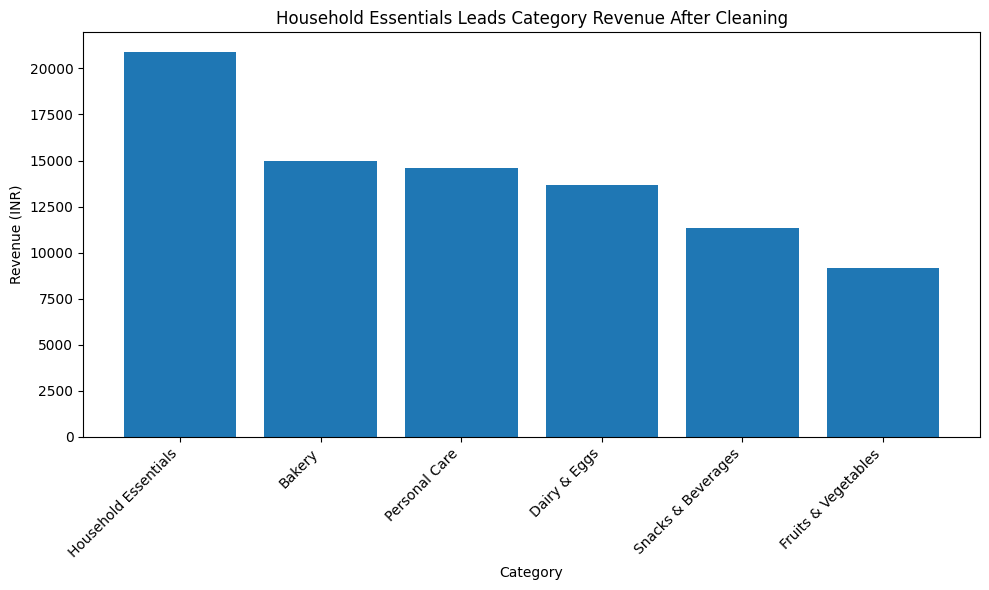

In [ ]:
# Task 8A — Category Revenue Bar Chart

plt.figure(figsize=(10, 6))

plt.bar(
    category_revenue["category"],
    category_revenue["total_revenue"]
)

plt.title("Household Essentials Leads Category Revenue After Cleaning")
plt.xlabel("Category")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

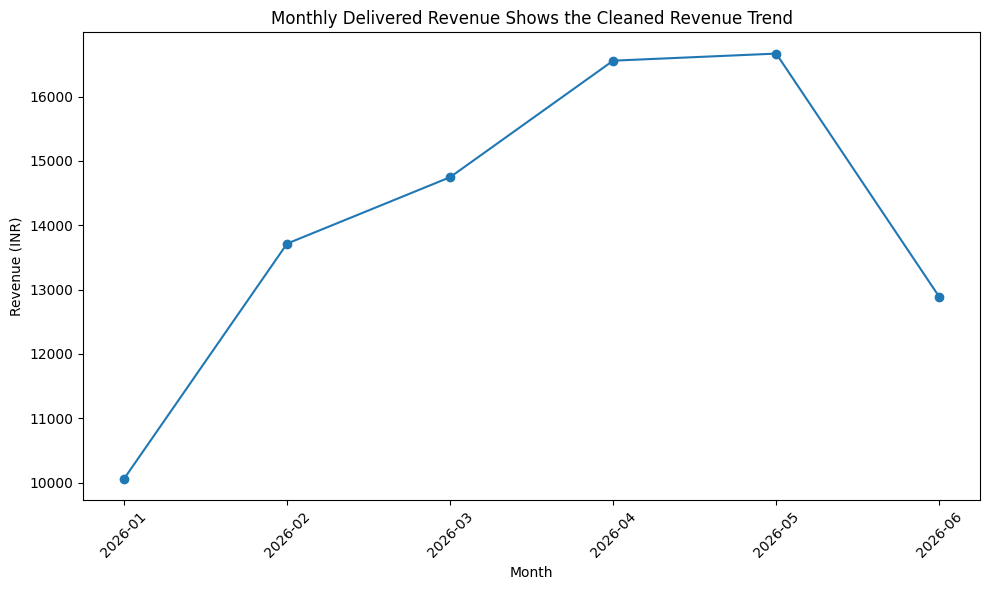

In [ ]:
# Task 8B — Monthly Delivered Revenue

monthly_revenue = (
    orders[
        (orders["status"] == "Delivered") &
        (orders["amount_inr"].notna())
    ]
    .assign(
        amount_inr_clean=lambda x: x["amount_inr"].clip(upper=upper_fence)
    )
    .groupby("month", as_index=False)["amount_inr_clean"]
    .sum()
)

monthly_revenue["month"] = monthly_revenue["month"].astype(str)

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["amount_inr_clean"],
    marker="o"
)

plt.title("Monthly Delivered Revenue Shows the Cleaned Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

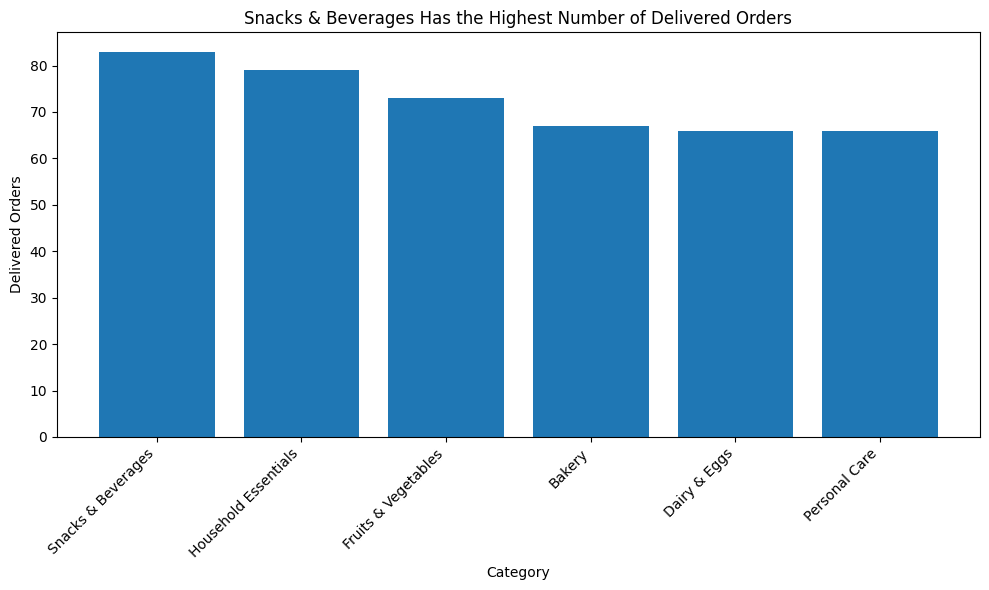

In [ ]:
# Task 8C — Delivered Orders by Category

category_orders = (
    orders[orders["status"] == "Delivered"]
    .groupby("category")
    .size()
    .reset_index(name="delivered_orders")
    .sort_values("delivered_orders", ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    category_orders["category"],
    category_orders["delivered_orders"]
)

plt.title("Snacks & Beverages Has the Highest Number of Delivered Orders")
plt.xlabel("Category")
plt.ylabel("Delivered Orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Task 9 — Key Insights

### Observation 1
**What:** Household Essentials generated the highest cleaned Delivered revenue among the six categories.

**Why it matters:** It is the strongest-performing category in the cleaned analysis.

**Next step:** Continue monitoring Household Essentials performance and use it as a benchmark for other categories.

### Observation 2
**What:** HomeEssentials Traders was the highest-revenue supplier in the cleaned analysis.

**Why it matters:** Supplier-level performance shows that this supplier contributes the most revenue among the listed suppliers.

**Next step:** Continue monitoring revenue from HomeEssentials Traders in future order periods.

### Observation 3
**What:** The IQR analysis identified 16 upper outliers, and their values were capped at ₹552.50 instead of being removed.

**Why it matters:** Capping reduces the influence of unusually large order amounts while keeping the orders in the analysis.

**Next step:** Use the capped revenue values for the remaining category and monthly analysis.

In [ ]:
check = delivered.loc[
    delivered["amount_inr"] > upper_fence,
    ["order_id", "amount_inr", "amount_inr_capped"]
].head(3)

display(check)

,order_id,amount_inr,amount_inr_capped
78,79,600.0,552.5
120,121,580.0,552.5
130,131,580.0,552.5


In [ ]:
orders["amount_inr_clean"] = orders["amount_inr"].clip(upper=upper_fence)

orders["revenue_per_unit"] = (
    orders["amount_inr_clean"] / orders["quantity"]
)

print("Derived columns created successfully.")
display(
    orders[
        ["order_id", "amount_inr", "amount_inr_clean",
         "quantity", "revenue_per_unit", "is_delivered"]
    ].head()
)

Derived columns created successfully.


,order_id,amount_inr,amount_inr_clean,quantity,revenue_per_unit,is_delivered
0,1,175.0,175.0,5,35.0,True
1,2,60.0,60.0,1,60.0,True
2,3,150.0,150.0,2,75.0,True
3,4,30.0,30.0,1,30.0,True
4,5,220.0,220.0,2,110.0,True


In [ ]:
print("Final cleaned revenue by category:")
display(category_revenue)

print("Top category:", category_revenue.iloc[0]["category"])

Final cleaned revenue by category:


,category,total_revenue
3,Household Essentials,20910.0
0,Bakery,14975.0
4,Personal Care,14594.5
1,Dairy & Eggs,13675.0
5,Snacks & Beverages,11312.5
2,Fruits & Vegetables,9170.0


Top category: Household Essentials


In [ ]:
print("Top supplier:", supplier_revenue.iloc[0]["supplier"])

Top supplier: HomeEssentials Traders


In [ ]:
print("Top category:", category_revenue.iloc[0]["category"])

Top category: Household Essentials
